In [1]:
!pip install -q transformers torch pandas

In [2]:
import torch
import pandas as pd
from transformers import GPT2Tokenizer, GPT2LMHeadModel

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
MODEL_NAME = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
model = GPT2LMHeadModel.from_pretrained(MODEL_NAME)

model.eval()

print("GPT-2 loaded successfully!")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded successfully!


In [4]:
prompt = "The capital of France is"

inputs = tokenizer(prompt, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

next_token_logits = logits[0, -1, :]

top_k = 5
top_values, top_indices = torch.topk(next_token_logits, top_k)

print("Prompt:", prompt)
print("\nTop 5 predictions:")

for value, index in zip(top_values, top_indices):
    token = tokenizer.decode([index])
    print(f"{token!r}: {value.item():.4f}")

Prompt: The capital of France is

Top 5 predictions:
' the': -100.2498
' now': -100.8175
' a': -100.8555
' France': -101.2101
' Paris': -101.2143


In [10]:
def logit_lens(prompt, top_k=5):
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True
        )

    hidden_states = outputs.hidden_states
    results = []

    for layer_number, hidden_state in enumerate(hidden_states):

        final_hidden = hidden_state[:, -1, :]

        # GPT-2's final hidden state is already normalized.
        # Apply ln_f only to the earlier layers.
        if layer_number < len(hidden_states) - 1:
            final_hidden = model.transformer.ln_f(final_hidden)

        logits = model.lm_head(final_hidden)

        top_values, top_indices = torch.topk(logits, top_k)

        predictions = []

        for value, index in zip(top_values[0], top_indices[0]):
            token = tokenizer.decode([index]).strip()

            predictions.append(
                f"{token} ({value.item():.2f})"
            )

        results.append({
            "Layer": layer_number,
            "Top Predictions": predictions
        })

    return pd.DataFrame(results)


prompt = "The capital of France is"

df = logit_lens(prompt, top_k=5)

display(df)

,Layer,Top Predictions
0,0,"[destro (87.56), mathemat (86.91), livest (85...."
1,1,"[not (6.00), now (5.05), still (4.61), also (4..."
2,2,"[now (5.79), not (5.74), also (5.24), still (4..."
3,3,"[now (4.26), not (3.50), also (3.38), still (2..."
4,4,"[now (3.64), also (2.37), not (2.23), currentl..."
5,5,"[now (1.37), not (-0.68), also (-1.09), still ..."
6,6,"[now (-1.10), still (-2.72), not (-2.94), also..."
7,7,"[now (-5.08), not (-6.62), still (-7.41), also..."
8,8,"[now (-8.63), also (-11.03), still (-11.09), n..."
9,9,"[now (-12.86), located (-13.93), also (-14.64)..."


## Results

The experiment was conducted using five factual prompts. The table below summarizes the layer at which each expected answer reached its maximum probability and the corresponding probability value.


In [15]:
results_table = []

for name, scores in all_results.items():
    peak_layer = scores.index(max(scores))
    peak_probability = max(scores)

    results_table.append({
        "Prompt": name,
        "Peak Layer": peak_layer,
        "Maximum Probability": f"{peak_probability:.2%}"
    })

results_df = pd.DataFrame(results_table)

display(results_df)

,Prompt,Peak Layer,Maximum Probability
0,France → Paris,10,18.19%
1,Japan → Tokyo,11,46.11%
2,Planet → Jupiter,11,36.44%
3,Water → 0,11,3.08%
4,Eiffel Tower → Paris,11,1.29%


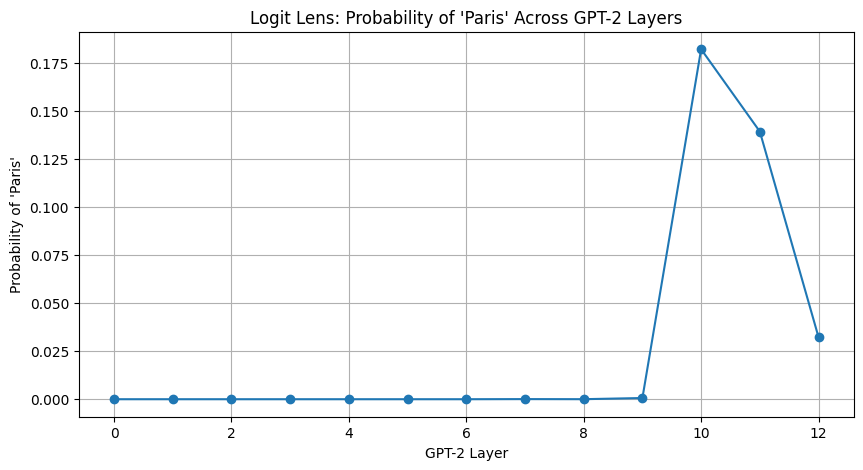

In [11]:
import matplotlib.pyplot as plt

def get_token_scores(prompt, target_token):
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True
        )

    scores = []

    # Get the token ID for the target
    target_id = tokenizer.encode(
        target_token,
        add_special_tokens=False
    )[0]

    for layer_number, hidden_state in enumerate(outputs.hidden_states):

        hidden = hidden_state[:, -1, :]

        # Final hidden state is already normalized
        if layer_number < len(outputs.hidden_states) - 1:
            hidden = model.transformer.ln_f(hidden)

        logits = model.lm_head(hidden)

        # Convert logits to probability
        probabilities = torch.softmax(logits, dim=-1)

        probability = probabilities[0, target_id].item()

        scores.append(probability)

    return scores


prompt = "The capital of France is"

paris_scores = get_token_scores(prompt, " Paris")

plt.figure(figsize=(10, 5))

plt.plot(
    range(len(paris_scores)),
    paris_scores,
    marker="o"
)

plt.xlabel("GPT-2 Layer")
plt.ylabel("Probability of 'Paris'")
plt.title("Logit Lens: Probability of 'Paris' Across GPT-2 Layers")
plt.grid(True)

plt.show()

In [12]:
tokens = tokenizer.encode(" Paris", add_special_tokens=False)

print("Token IDs:", tokens)
print("Decoded tokens:", [tokenizer.decode([t]) for t in tokens])

Token IDs: [6342]
Decoded tokens: [' Paris']


In [13]:
prompts = {
    "France → Paris": ("The capital of France is", " Paris"),
    "Japan → Tokyo": ("The capital of Japan is", " Tokyo"),
    "Planet → Jupiter": (
        "The largest planet in our solar system is",
        " Jupiter"
    ),
    "Water → 0": ("Water freezes at", " 0"),
    "Eiffel Tower → Paris": (
        "The Eiffel Tower is located in",
        " Paris"
    )
}


def get_token_probability(prompt, target_token):
    inputs = tokenizer(prompt, return_tensors="pt")

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True
        )

    target_ids = tokenizer.encode(
        target_token,
        add_special_tokens=False
    )

    if len(target_ids) != 1:
        return None

    target_id = target_ids[0]
    probabilities = []

    for layer_number, hidden_state in enumerate(outputs.hidden_states):

        hidden = hidden_state[:, -1, :]

        # Apply final layer normalization to intermediate states
        if layer_number < len(outputs.hidden_states) - 1:
            hidden = model.transformer.ln_f(hidden)

        logits = model.lm_head(hidden)

        probs = torch.softmax(logits, dim=-1)

        probabilities.append(
            probs[0, target_id].item()
        )

    return probabilities


all_results = {}

for name, (prompt, target) in prompts.items():

    scores = get_token_probability(prompt, target)

    if scores is not None:
        all_results[name] = scores


print("Experiment completed!")

for name, scores in all_results.items():
    print(
        f"{name}: "
        f"maximum probability = {max(scores):.4f}, "
        f"layer = {scores.index(max(scores))}"
    )

Experiment completed!
France → Paris: maximum probability = 0.1819, layer = 10
Japan → Tokyo: maximum probability = 0.4611, layer = 11
Planet → Jupiter: maximum probability = 0.3644, layer = 11
Water → 0: maximum probability = 0.0308, layer = 11
Eiffel Tower → Paris: maximum probability = 0.0129, layer = 11


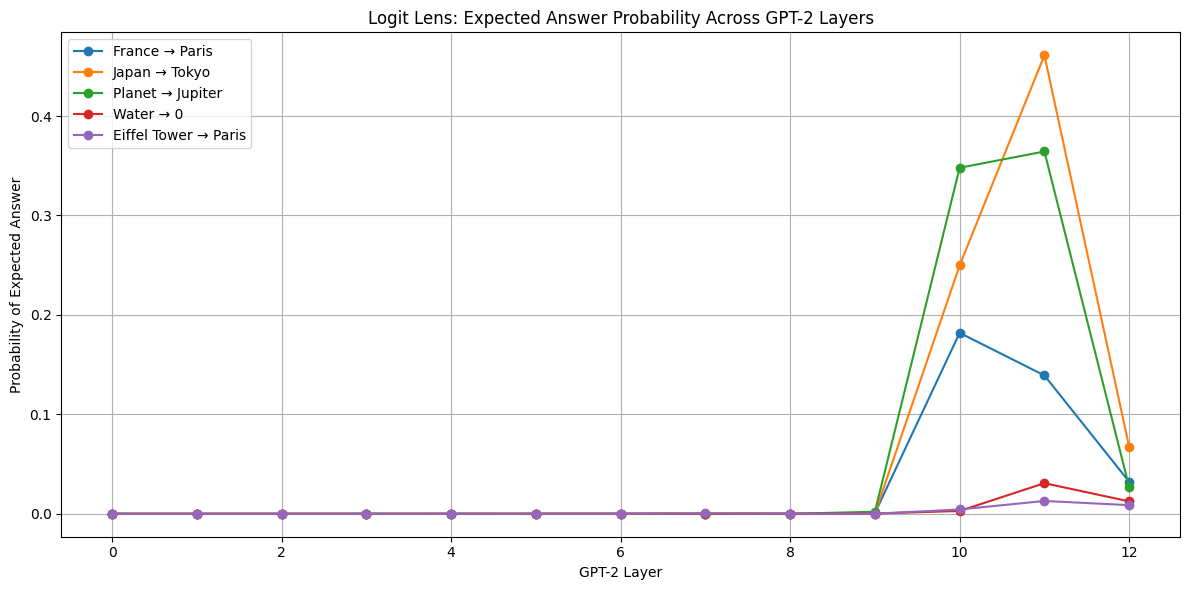

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for name, scores in all_results.items():
    plt.plot(
        range(len(scores)),
        scores,
        marker="o",
        label=name
    )

plt.xlabel("GPT-2 Layer")
plt.ylabel("Probability of Expected Answer")
plt.title("Logit Lens: Expected Answer Probability Across GPT-2 Layers")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

# Conclusion

This project used Logit Lens analysis to investigate how GPT-2 develops predictions across its transformer layers. By projecting intermediate hidden representations into the vocabulary space, we tracked the probability of expected answer tokens for several factual prompts.

The results showed that the expected-answer tokens generally became more prominent around layers 10–11. However, the strength of this signal varied significantly between prompts. For example, the token "Tokyo" reached a maximum probability of approximately 46%, while "Paris" for the France prompt reached approximately 18%.

These results demonstrate that model predictions are not formed uniformly across all layers. Instead, useful semantic information can become visible in intermediate representations before the final output layer.

Overall, the experiment provides a simple demonstration of how Logit Lens can be used as an interpretability technique to study the internal representations of a language model.

# Limitations

1. **Small model size:** This experiment uses GPT-2, which is relatively small compared with modern large language models.

2. **Limited prompts:** Only five factual prompts were evaluated, so the findings cannot be generalized to all types of language tasks.

3. **Single-token analysis:** The probability analysis focuses on expected answers represented by individual GPT-2 tokens. Multi-token answers require additional handling.

4. **Logit Lens is a probing technique:** Projecting intermediate representations through the language-model head does not necessarily represent exactly what the model "thinks" at that layer.

5. **Limited evaluation:** The experiment does not compare multiple model architectures or model sizes.

6. **Prompt sensitivity:** Results can change depending on the wording and structure of the input prompt.

# Future Work

- Compare Logit Lens behavior across different GPT-2 model sizes.
- Analyze multi-token answers.
- Test a larger and more diverse set of prompts.
- Compare Logit Lens with other interpretability techniques.
- Study how attention patterns and hidden representations contribute to prediction formation.
- Investigate whether similar layer-wise patterns occur across different language models.

# GPT-2 Logit Lens Analysis

## Project Overview

This project investigates how GPT-2 develops factual predictions across its transformer layers using the **Logit Lens** interpretability technique.

Instead of looking only at GPT-2's final prediction, the project projects intermediate hidden representations into the model's vocabulary space. This allows us to observe which tokens become more probable at different layers of the network.

The experiment evaluates several factual prompts and visualizes how the probability of the expected answer changes across GPT-2's layers.

## Objectives

* Analyze GPT-2's intermediate hidden representations.
* Implement the Logit Lens technique using Python and PyTorch.
* Track expected-answer token probabilities across transformer layers.
* Compare the layer-wise behavior across multiple factual prompts.
* Visualize how predictions emerge and change throughout the model.
* Explore the usefulness and limitations of Logit Lens for language-model interpretability.
